# Master Summary — Bubble Detection in Metal Prices

## What This Study Does

We try to **predict price bubbles** in four metals (Cobalt, Copper, Lithium, Nickel) using
machine learning. A bubble is a period where the price rises sharply above its normal level
and then falls back — like a spike on a chart.

The key question: **can we detect these bubbles as they're forming** (not after the crash)?

## Two Ways to Define "Bubble" (Labels)

| Method | How It Works | Character |
|--------|-------------|----------|
| **GSADF** | Statistical test (Phillips et al. 2015) that detects "explosive" price behaviour. Pre-computed in R. | Labels **entire periods** as bubbles. Conservative — finds fewer but longer episodes. |
| **LPPLS** | Fits a log-periodic power law model (Sornette) to detect super-exponential growth. Outputs a daily confidence score. | Labels **individual days**. We threshold the confidence and post-process into periods. |

### LPPLS Variants Tested

We tested 5 LPPLS confidence thresholds plus a "period-based" version that smooths
the raw signal into coherent episodes:

- **lppls_0.30** — Very strict, few days flagged
- **lppls_0.20** — Moderate  
- **lppls_0.10** — Permissive
- **lppls_0.05** — Very permissive
- **lppls_period** — Smoothed + gap-bridged + minimum 3-day episodes

All variants include a **trend filter**: only flag a day if the price is higher than 5 days ago.

## Three ML Models

| Model | Type | Key Property |
|-------|------|-------------|
| **LASSO** | L1-penalized logistic regression | Linear, interpretable, selects important features |
| **Random Forest** | Ensemble of decision trees | Non-linear, robust to noise |
| **XGBoost** | Gradient-boosted trees | Non-linear, often best for tabular data |

### Features (All Lagged by 1 Day — No Look-Ahead)

- Log-returns and 10-day rolling volatility for each metal
- Lagged price levels
- Peer metal bubble dummies (is another metal currently in a bubble?)

### Evaluation

- **5-fold expanding-window** time series cross-validation
- **No SMOTE** (oversampling led to detecting only one cluster)
- Key metrics: **AUC**, **F1** (threshold-optimised), **Sensitivity**, **Episode detection rate**

---

*Total: 4 metals × 6 label variants × 3 models = **72 experiments***

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'

df_all = pd.read_csv('../outputs/all_results.csv')
df_labels = pd.read_csv('../outputs/all_labels.csv')
df_labels['Date'] = pd.to_datetime(df_labels['Date'])

# Filter valid results
df_r = df_all[(df_all.Note != 'too_few_pos') & df_all.AUC.notna()].copy()

print(f'Total experiments: {len(df_all)}')
print(f'Valid experiments: {len(df_r)}')
print(f'Metals: {sorted(df_r.Metal.unique())}')
print(f'Variants: {sorted(df_r.Variant.unique())}')
print(f'Models: {sorted(df_r.Model.unique())}')

Total experiments: 200
Valid experiments: 190
Metals: ['Cobalt', 'Copper', 'Lithium', 'Nickel']
Variants: ['gsadf_ols', 'gsadf_ols_period', 'gsadf_v1', 'gsadf_v1_period', 'lppls_0.01', 'lppls_0.01_period', 'lppls_0.05', 'lppls_0.05_period', 'lppls_0.10', 'lppls_0.10_period']
Models: ['CatBoost', 'LASSO', 'LightGBM', 'RF', 'XGBoost']


## 1. Bubble Label Overview

How many bubble days does each method find per metal?

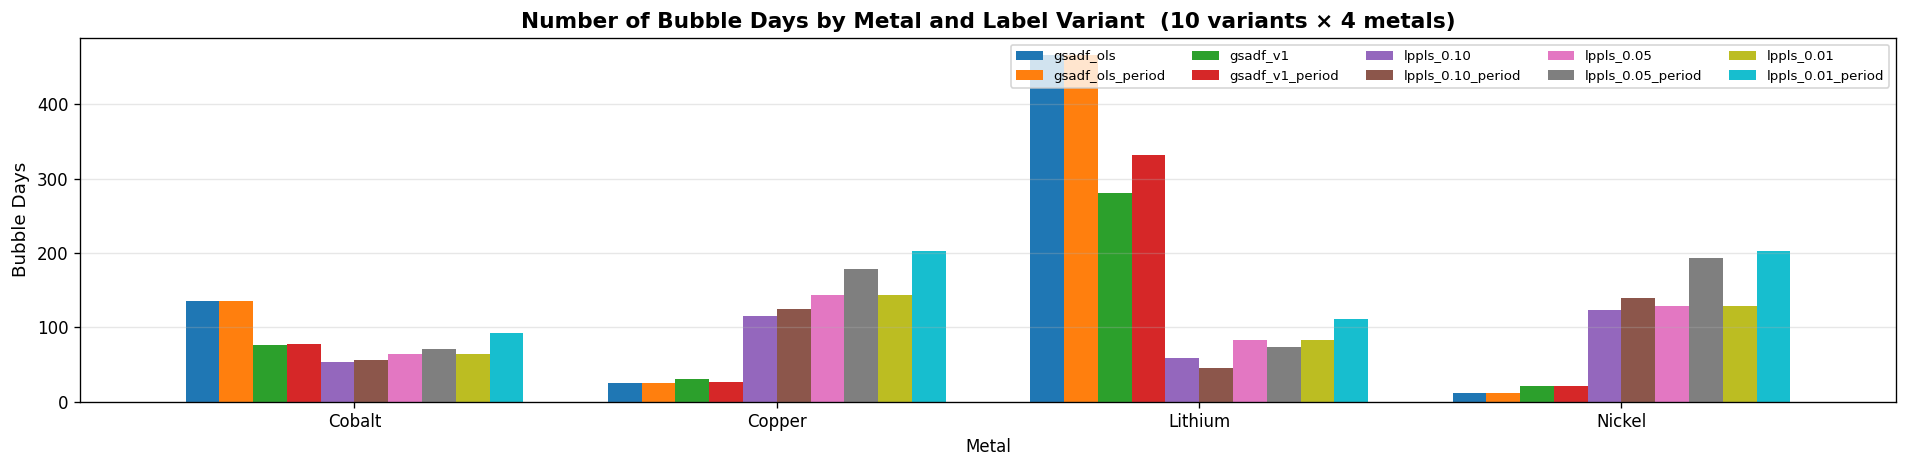


Bubble days summary:
   Metal                 Variant   Days   Prev%  Episodes
  Cobalt               gsadf_ols    135    6.3%         8
  Cobalt        gsadf_ols_period    135    6.3%         8
  Cobalt                gsadf_v1     76    3.5%        11
  Cobalt         gsadf_v1_period     77    3.6%         6
  Cobalt              lppls_0.10     53    2.5%         7
  Cobalt       lppls_0.10_period     56    2.6%         4
  Cobalt              lppls_0.05     64    3.0%         8
  Cobalt       lppls_0.05_period     71    3.3%         5
  Cobalt              lppls_0.01     64    3.0%         8
  Cobalt       lppls_0.01_period     92    4.3%         6
  Copper               gsadf_ols     25    1.2%         2
  Copper        gsadf_ols_period     25    1.2%         2
  Copper                gsadf_v1     31    1.4%         5
  Copper         gsadf_v1_period     27    1.3%         3
  Copper              lppls_0.10    115    5.3%        25
  Copper       lppls_0.10_period    125    5.8%   

In [2]:
METALS = {'Cobalt': 'CODALY', 'Copper': 'CUDALY', 'Lithium': 'LIDALY', 'Nickel': 'NIDALY'}
VARIANTS = [
    'gsadf_ols', 'gsadf_ols_period', 'gsadf_v1', 'gsadf_v1_period',
    'lppls_0.10', 'lppls_0.10_period',
    'lppls_0.05', 'lppls_0.05_period',
    'lppls_0.01', 'lppls_0.01_period',
]

def count_episodes(arr):
    d = np.diff(np.concatenate([[0], arr, [0]]))
    starts = np.where(d == 1)[0]
    ends   = np.where(d == -1)[0]
    if len(starts) == 0:
        return 0, 0.0
    return len(starts), float(np.mean(ends - starts))

# Build summary
rows = []
for metal in METALS:
    for v in VARIANTS:
        col = f'{metal}_{v}'
        if col in df_labels.columns:
            arr = df_labels[col].values
            n   = int(arr.sum())
            n_ep, avg_l = count_episodes(arr)
            rows.append({'Metal': metal, 'Variant': v, 'Days': n,
                         'Prevalence': f'{100*n/len(df_labels):.1f}%',
                         'Episodes': n_ep, 'Avg_Len': f'{avg_l:.1f}d'})

df_summary = pd.DataFrame(rows)
pivot_days  = df_summary.pivot_table(index='Metal', columns='Variant', values='Days')
pivot_days  = pivot_days.reindex(columns=VARIANTS)

fig, ax = plt.subplots(figsize=(16, 4))
pivot_days.plot(kind='bar', ax=ax, width=0.8)
ax.set_ylabel('Bubble Days', fontsize=11)
ax.set_title('Number of Bubble Days by Metal and Label Variant  (10 variants × 4 metals)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=8, ncol=5, loc='upper right')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/03_bubble_days.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Print summary table
print(f'\nBubble days summary:')
print(f'{"Metal":>8s}  {"Variant":>22s}  {"Days":>5s}  {"Prev%":>6s}  {"Episodes":>8s}')
for _, r in df_summary.iterrows():
    print(f'{r.Metal:>8s}  {r.Variant:>22s}  {r.Days:>5d}  {r.Prevalence:>6s}  {r.Episodes:>8d}')


## Experiment A: Detection Method Quality

**Question:** Which labeling approach produces signals that ML models can *consistently* learn from?

To isolate label quality from model choice, we compute **mean F1 across all 5 models** per (Metal × Variant) cell.  
This removes the confound where a strong model makes a noisy label look artificially good.

We show this alongside the **best-of-models** view (the ceiling each label can reach).


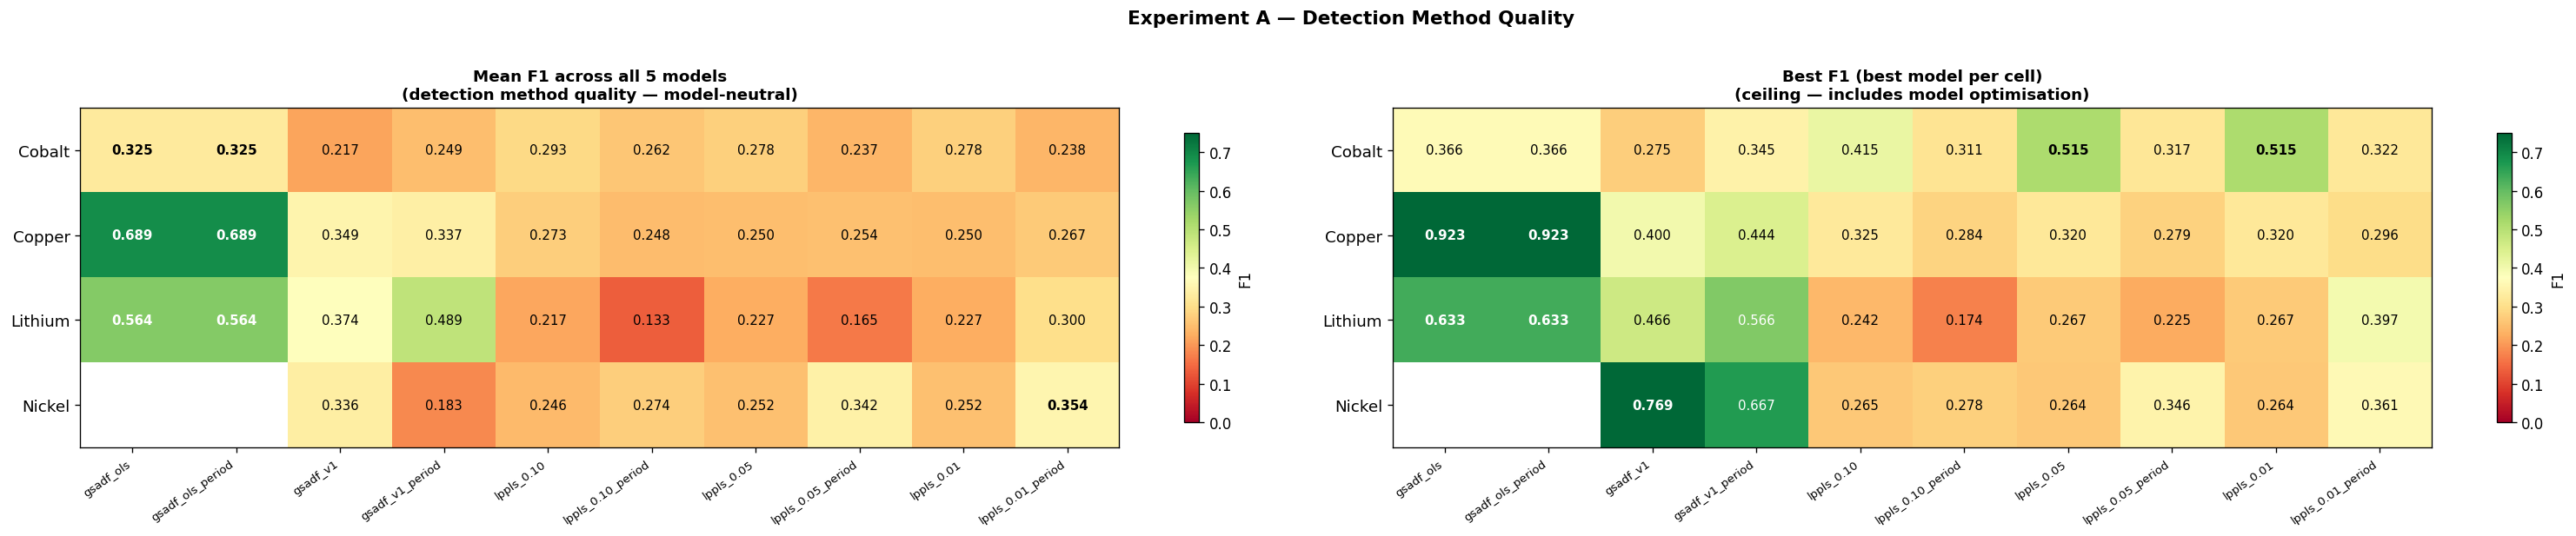

★ Best label variant per metal (mean-across-models view):
  Cobalt   → gsadf_ols              [GSADF]  mean F1=0.325  (ceiling F1=0.366 with LASSO)
  Copper   → gsadf_ols              [GSADF]  mean F1=0.689  (ceiling F1=0.923 with LASSO)
  Lithium  → gsadf_ols              [GSADF]  mean F1=0.564  (ceiling F1=0.633 with XGBoost)
  Nickel   → lppls_0.01_period      [LPPLS]  mean F1=0.354  (ceiling F1=0.361 with LASSO)


In [3]:
METAL_ORDER = ['Cobalt', 'Copper', 'Lithium', 'Nickel']
MODEL_ORDER = ['LASSO', 'RF', 'XGBoost', 'LightGBM', 'CatBoost']

# ── Two views: mean-across-models (fair) vs best-of-models (ceiling) ──────
pivot_mean_f1 = (df_r.groupby(['Metal', 'Variant'])['F1'].mean()
                 .unstack('Variant')
                 .reindex(columns=VARIANTS, index=METAL_ORDER))

best = df_r.loc[df_r.groupby(['Metal', 'Variant'])['F1'].idxmax()].copy()
pivot_best_f1 = (best.pivot_table(index='Metal', columns='Variant', values='F1')
                 .reindex(columns=VARIANTS, index=METAL_ORDER))
pivot_best_model = (best.pivot_table(index='Metal', columns='Variant',
                                     values='Model', aggfunc='first')
                    .reindex(columns=VARIANTS, index=METAL_ORDER))

fig, axes = plt.subplots(1, 2, figsize=(26, 5))
titles = ['Mean F1 across all 5 models\n(detection method quality — model-neutral)',
          'Best F1 (best model per cell)\n(ceiling — includes model optimisation)']

for ax, pivot, title in zip(axes, [pivot_mean_f1, pivot_best_f1], titles):
    im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=0.75)
    ax.set_xticks(range(len(VARIANTS)))
    ax.set_xticklabels(VARIANTS, rotation=35, ha='right', fontsize=8)
    ax.set_yticks(range(len(METAL_ORDER)))
    ax.set_yticklabels(METAL_ORDER, fontsize=11)
    for i in range(len(METAL_ORDER)):
        for j in range(len(VARIANTS)):
            val = pivot.iloc[i, j]
            if not np.isnan(val):
                row_max = pivot.iloc[i].max()
                bold = 'bold' if val == row_max else 'normal'
                tc   = 'white' if val > 0.55 or val < 0.12 else 'black'
                ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                        fontsize=9, fontweight=bold, color=tc)
    plt.colorbar(im, ax=ax, shrink=0.85, label='F1')
    ax.set_title(title, fontsize=11, fontweight='bold')

plt.suptitle('Experiment A — Detection Method Quality', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/03_exp_a_detection_quality.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

# Summary text
GSADF_V = [v for v in VARIANTS if v.startswith('gsadf')]
LPPLS_V = [v for v in VARIANTS if v.startswith('lppls')]

print('★ Best label variant per metal (mean-across-models view):')
for metal in METAL_ORDER:
    winner  = pivot_mean_f1.loc[metal].idxmax()
    mean_f1 = pivot_mean_f1.loc[metal].max()
    best_f1 = pivot_best_f1.loc[metal, winner]
    bmodel  = pivot_best_model.loc[metal, winner]
    method  = 'GSADF' if winner.startswith('gsadf') else 'LPPLS'
    print(f'  {metal:8s} → {winner:22s} [{method}]  mean F1={mean_f1:.3f}  '
          f'(ceiling F1={best_f1:.3f} with {bmodel})')


## Experiment B: Model Performance

**Question:** Which model architecture handles which detection method and which metal best?

- **Model × Variant** heatmap: mean F1 averaged across all 4 metals — isolates model/method interaction
- **Model × Metal** heatmap: mean F1 averaged across all 6 variants — isolates model/metal interaction
- **Overall averages** bar chart: the global aggregate picture


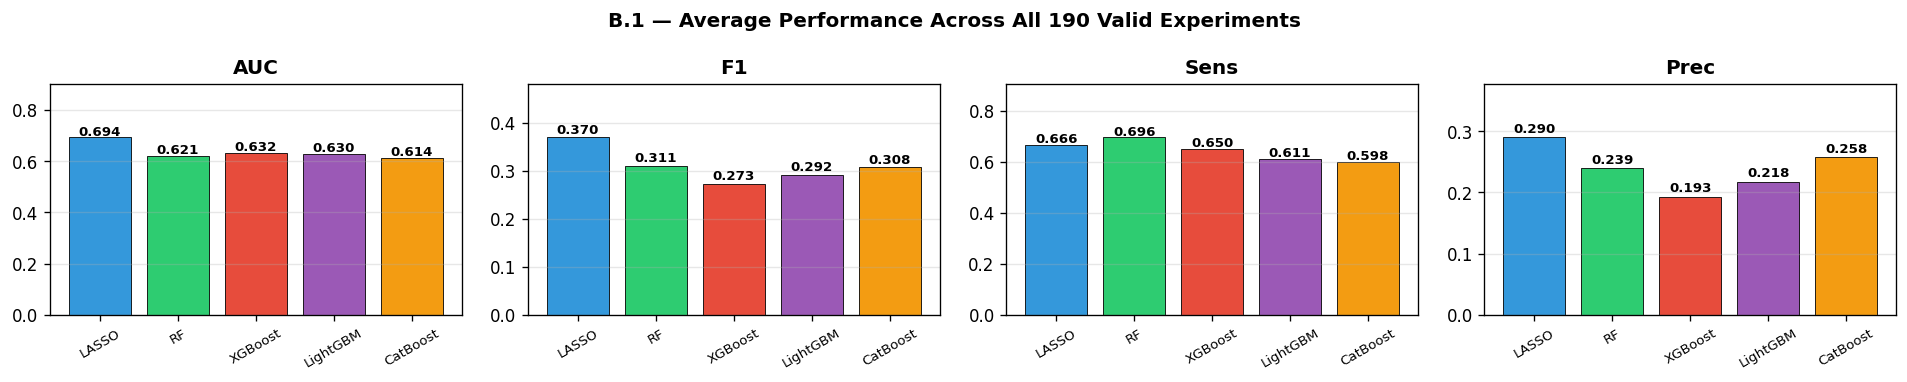

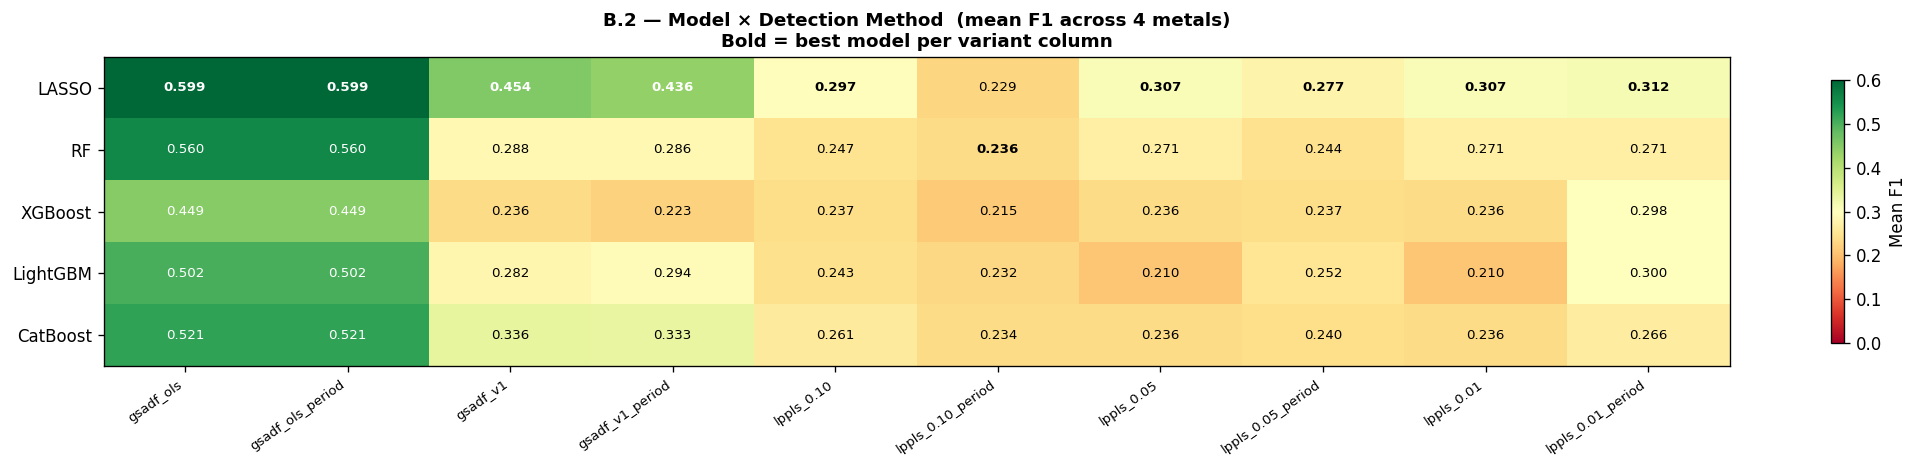

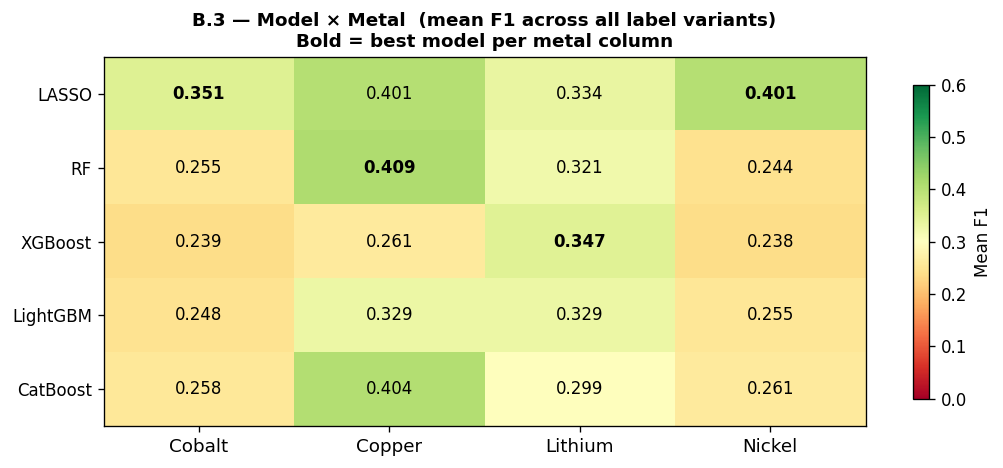

In [4]:
palette = {'LASSO': '#3498db', 'RF': '#2ecc71', 'XGBoost': '#e74c3c',
           'LightGBM': '#9b59b6', 'CatBoost': '#f39c12'}
models_present = [m for m in MODEL_ORDER if m in df_r.Model.unique()]
n_exp = len(df_r.groupby(['Metal', 'Variant', 'Model']))

# ── B.1. Global avg bars ──────────────────────────────────────────────────
model_avg = df_r.groupby('Model')[['AUC', 'F1', 'Sens', 'Prec']].mean().reindex(models_present)
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
for idx, metric in enumerate(['AUC', 'F1', 'Sens', 'Prec']):
    ax = axes[idx]
    vals = model_avg[metric]
    bars = ax.bar(vals.index, vals.values,
                  color=[palette[m] for m in vals.index],
                  edgecolor='black', lw=0.5)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0, vals.max() * 1.30)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')
plt.suptitle(f'B.1 — Average Performance Across All {n_exp} Valid Experiments',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/03_exp_b1_model_avg.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

# ── B.2. Model × Variant heatmap (mean across metals) ────────────────────
pivot_mv = (df_r.groupby(['Model', 'Variant'])['F1'].mean()
            .unstack('Variant')
            .reindex(index=models_present, columns=VARIANTS))

fig, ax = plt.subplots(figsize=(18, 4))
im = ax.imshow(pivot_mv.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=0.6)
ax.set_xticks(range(len(VARIANTS)))
ax.set_xticklabels(VARIANTS, rotation=35, ha='right', fontsize=8)
ax.set_yticks(range(len(models_present)))
ax.set_yticklabels(models_present, fontsize=10)
for i in range(len(models_present)):
    for j in range(len(VARIANTS)):
        val = pivot_mv.iloc[i, j]
        if not np.isnan(val):
            col_max = pivot_mv.iloc[:, j].max()
            bold = 'bold' if val == col_max else 'normal'
            tc   = 'white' if val > 0.42 or val < 0.08 else 'black'
            ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                    fontsize=8, fontweight=bold, color=tc)
plt.colorbar(im, ax=ax, shrink=0.85, label='Mean F1')
ax.set_title('B.2 — Model × Detection Method  (mean F1 across 4 metals)\n'
             'Bold = best model per variant column',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/03_exp_b2_model_variant.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

# ── B.3. Model × Metal heatmap (mean across variants) ────────────────────
pivot_mm = (df_r.groupby(['Model', 'Metal'])['F1'].mean()
            .unstack('Metal')
            .reindex(index=models_present, columns=METAL_ORDER))

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(pivot_mm.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=0.6)
ax.set_xticks(range(len(METAL_ORDER)))
ax.set_xticklabels(METAL_ORDER, fontsize=11)
ax.set_yticks(range(len(models_present)))
ax.set_yticklabels(models_present, fontsize=10)
for i in range(len(models_present)):
    for j in range(len(METAL_ORDER)):
        val = pivot_mm.iloc[i, j]
        if not np.isnan(val):
            col_max = pivot_mm.iloc[:, j].max()
            bold = 'bold' if val == col_max else 'normal'
            tc   = 'white' if val > 0.42 or val < 0.08 else 'black'
            ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                    fontsize=10, fontweight=bold, color=tc)
plt.colorbar(im, ax=ax, shrink=0.85, label='Mean F1')
ax.set_title('B.3 — Model × Metal  (mean F1 across all label variants)\n'
             'Bold = best model per metal column',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/03_exp_b3_model_metal.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()


## Experiment C: Optimal Combination — Best (Method + Model) per Metal

**Question:** Putting both dimensions together — what is the single best *(label variant, model)* pair for each metal?

The heatmap below shows the best achievable F1 per cell, with the **winning model** annotated inside.  
This is the full three-dimensional synthesis in a single view.


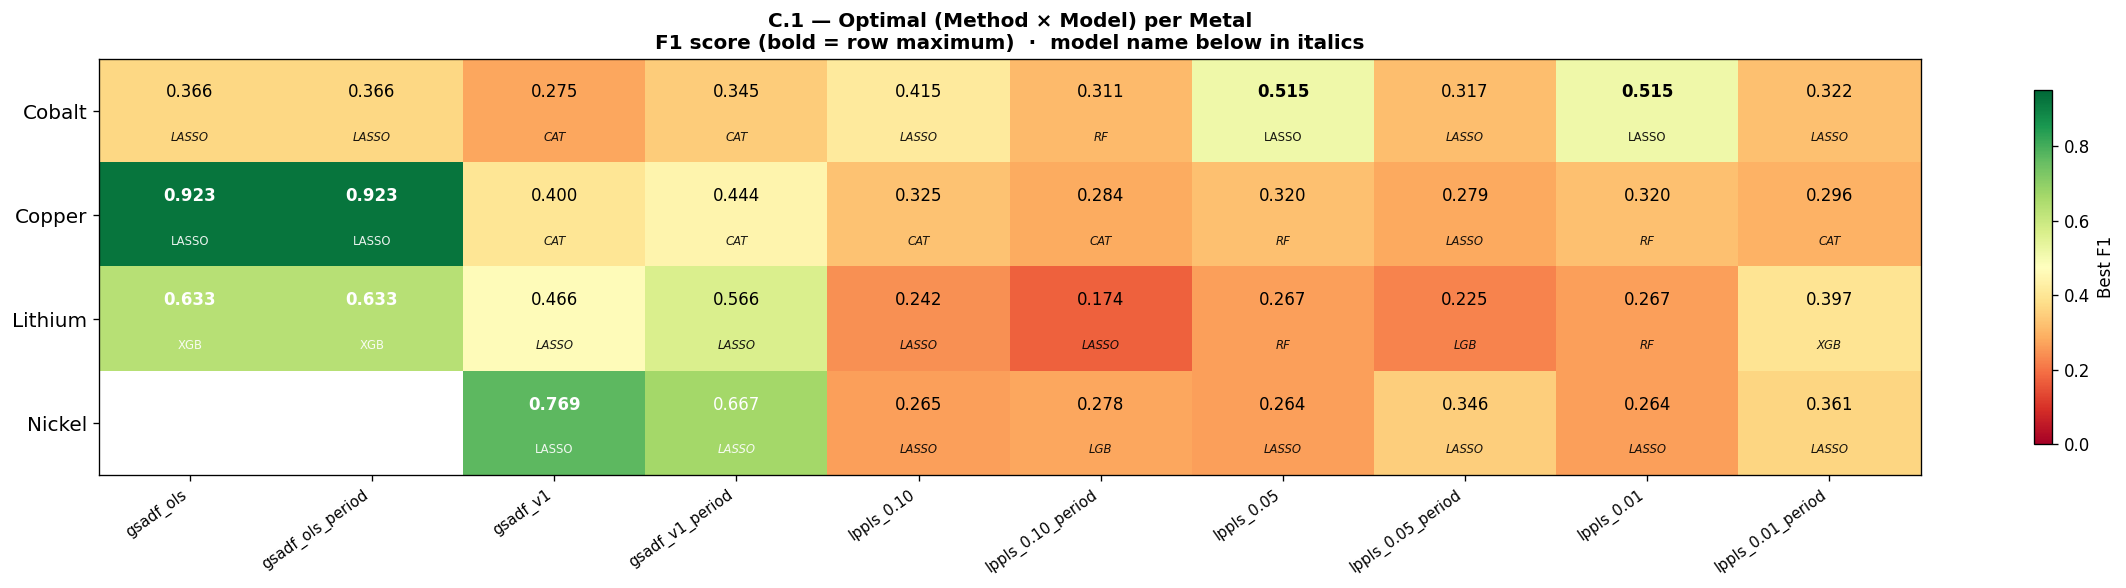


Final Recommendation — Best (Method, Model) per Metal:

   Metal        Detection Method       Model     F1    AUC   Sens   Prec  Episodes
──────────────────────────────────────────────────────────────────────────────────────────
  Cobalt              lppls_0.05       LASSO  0.515  0.909  0.593  0.455       5/7  [LPPLS]
  Copper               gsadf_ols       LASSO  0.923  0.998  0.857  1.000       1/1  [GSADF]
 Lithium               gsadf_ols     XGBoost  0.633  0.501  0.978  0.468       2/3  [GSADF]
  Nickel                gsadf_v1       LASSO  0.769  0.928  0.714  0.833       1/1  [GSADF]


In [5]:
MODEL_SHORT = {'LASSO': 'LASSO', 'RF': 'RF', 'XGBoost': 'XGB',
               'LightGBM': 'LGB', 'CatBoost': 'CAT'}

# ── Annotated combo heatmap ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 5))
im = ax.imshow(pivot_best_f1.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=0.95)

ax.set_xticks(range(len(VARIANTS)))
ax.set_xticklabels(VARIANTS, rotation=35, ha='right', fontsize=9)
ax.set_yticks(range(len(METAL_ORDER)))
ax.set_yticklabels(METAL_ORDER, fontsize=12)

for i in range(len(METAL_ORDER)):
    for j in range(len(VARIANTS)):
        f1_val   = pivot_best_f1.iloc[i, j]
        mod_name = pivot_best_model.iloc[i, j]
        if not np.isnan(f1_val):
            row_max = pivot_best_f1.iloc[i].max()
            bold = 'bold' if f1_val == row_max else 'normal'
            tc   = 'white' if f1_val > 0.62 or f1_val < 0.15 else 'black'
            ax.text(j, i - 0.18, f'{f1_val:.3f}', ha='center', va='center',
                    fontsize=10, fontweight=bold, color=tc)
            ax.text(j, i + 0.25, MODEL_SHORT.get(str(mod_name), str(mod_name)),
                    ha='center', va='center', fontsize=7,
                    color=tc, alpha=0.9,
                    style='italic' if bold == 'normal' else 'normal')

plt.colorbar(im, ax=ax, label='Best F1', shrink=0.85)
ax.set_title('C.1 — Optimal (Method × Model) per Metal\n'
             'F1 score (bold = row maximum)  ·  model name below in italics',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/03_exp_c_combo_heatmap.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

# ── Final recommendation table ─────────────────────────────────────────────
overall_best = df_r.loc[df_r.groupby('Metal')['F1'].idxmax()]
print('\nFinal Recommendation — Best (Method, Model) per Metal:\n')
print(f'{"Metal":>8s}  {"Detection Method":>22s}  {"Model":>10s}  '
      f'{"F1":>5s}  {"AUC":>5s}  {"Sens":>5s}  {"Prec":>5s}  {"Episodes":>8s}')
print('─' * 90)
for _, r in overall_best.iterrows():
    method = 'GSADF' if r.Variant.startswith('gsadf') else 'LPPLS'
    print(f'{r.Metal:>8s}  {r.Variant:>22s}  {r.Model:>10s}  '
          f'{r.F1:>5.3f}  {r.AUC:>5.3f}  {r.Sens:>5.3f}  {r.Prec:>5.3f}  {r.EpDet:>8s}  [{method}]')


## 4. Episode Detection — Can We Catch All Bubbles?

It's not just about flagging individual days — we want to detect **each bubble episode**
(even if we only catch one day of it). This is the "episode detection rate".

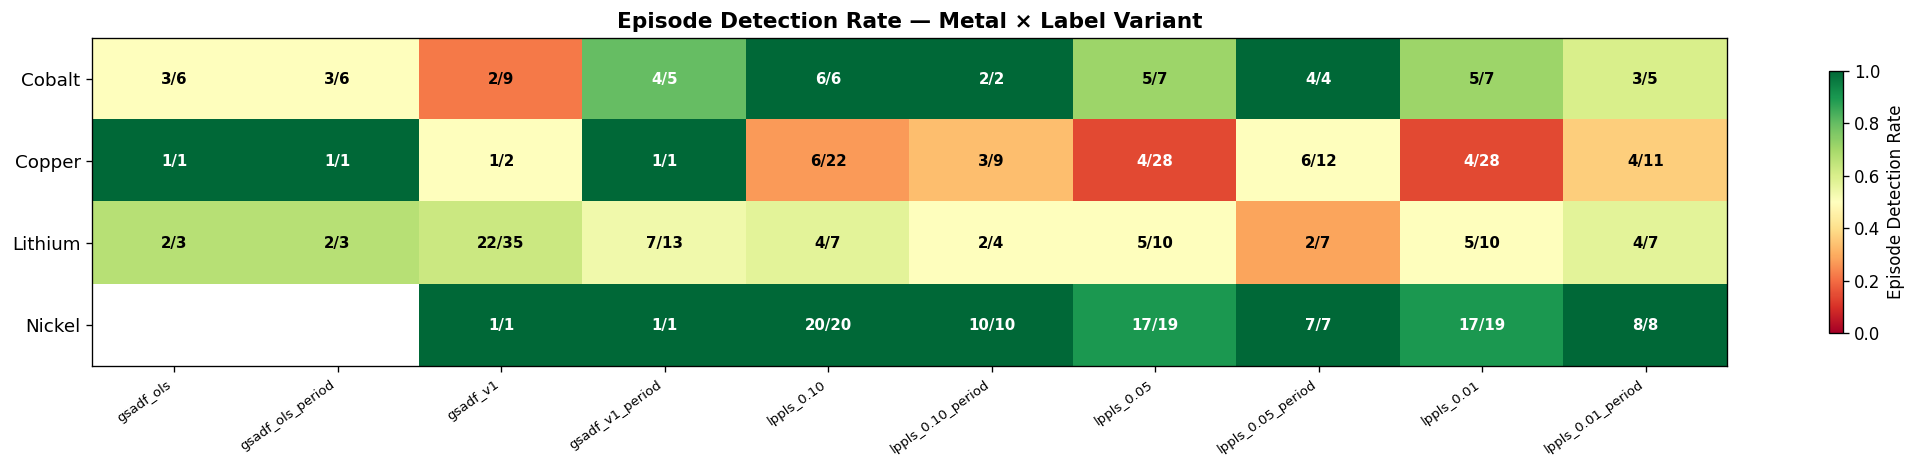

In [6]:
def ep_rate(s):
    parts = str(s).split('/')
    if len(parts) == 2 and int(parts[1]) > 0:
        return int(parts[0]) / int(parts[1])
    return np.nan

best['EpRate'] = best['EpDet'].apply(ep_rate)

pivot_ep = best.pivot_table(index='Metal', columns='Variant', values='EpRate')
pivot_ep = pivot_ep.reindex(columns=VARIANTS, index=METAL_ORDER)

fig, ax = plt.subplots(figsize=(18, 4))
im = ax.imshow(pivot_ep.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1.0)
ax.set_xticks(range(len(pivot_ep.columns)))
ax.set_xticklabels(pivot_ep.columns, rotation=35, ha='right', fontsize=8)
ax.set_yticks(range(len(pivot_ep.index)))
ax.set_yticklabels(pivot_ep.index, fontsize=11)

for i in range(len(pivot_ep.index)):
    for j in range(len(pivot_ep.columns)):
        val = pivot_ep.iloc[i, j]
        if not np.isnan(val):
            ep_str = best[(best.Metal == pivot_ep.index[i]) &
                          (best.Variant == pivot_ep.columns[j])]['EpDet'].values
            txt = ep_str[0] if len(ep_str) > 0 else f'{val:.0%}'
            ax.text(j, i, txt, ha='center', va='center', fontsize=9, fontweight='bold',
                    color='white' if val > 0.75 or val < 0.2 else 'black')

plt.colorbar(im, ax=ax, label='Episode Detection Rate', shrink=0.8)
ax.set_title('Episode Detection Rate — Metal × Label Variant',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/03_episode_detection.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


## 5. Optuna Fine-tuning & SHAP Feature Importance

### Optuna
After ranking all 120 experiments, we ran **Optuna** (Bayesian TPE, 35 trials) on
the winning combo per metal to squeeze out better hyperparameters than the initial
grid — without re-running all experiments.

### SHAP
**SHAP** (SHapley Additive exPlanations) answers: *which features actually drove
each bubble prediction?* Values are computed on the most recent ~20 % of each
metal's data (chronological hold-out), so there is no look-ahead.

- Red dots = feature value **high** → SHAP pushes towards bubble  
- Blue dots = feature value **low** → SHAP pushes away from bubble  
- Bar length = average magnitude of impact


Optuna Fine-tuning — AUC improvement over default hyperparameters:

   Metal         Variant       Model  AUC_base  AUC_tuned       Δ
-----------------------------------------------------------------
  Cobalt      lppls_0.05       LASSO     0.909      0.931  +0.022 ★
  Copper       gsadf_ols       LASSO     0.998      0.998  +0.000
 Lithium       gsadf_ols     XGBoost     0.501      0.785  +0.284 ★
  Nickel        gsadf_v1       LASSO     0.928      0.942  +0.014 ★

★ = meaningful improvement (Δ > 0.01)


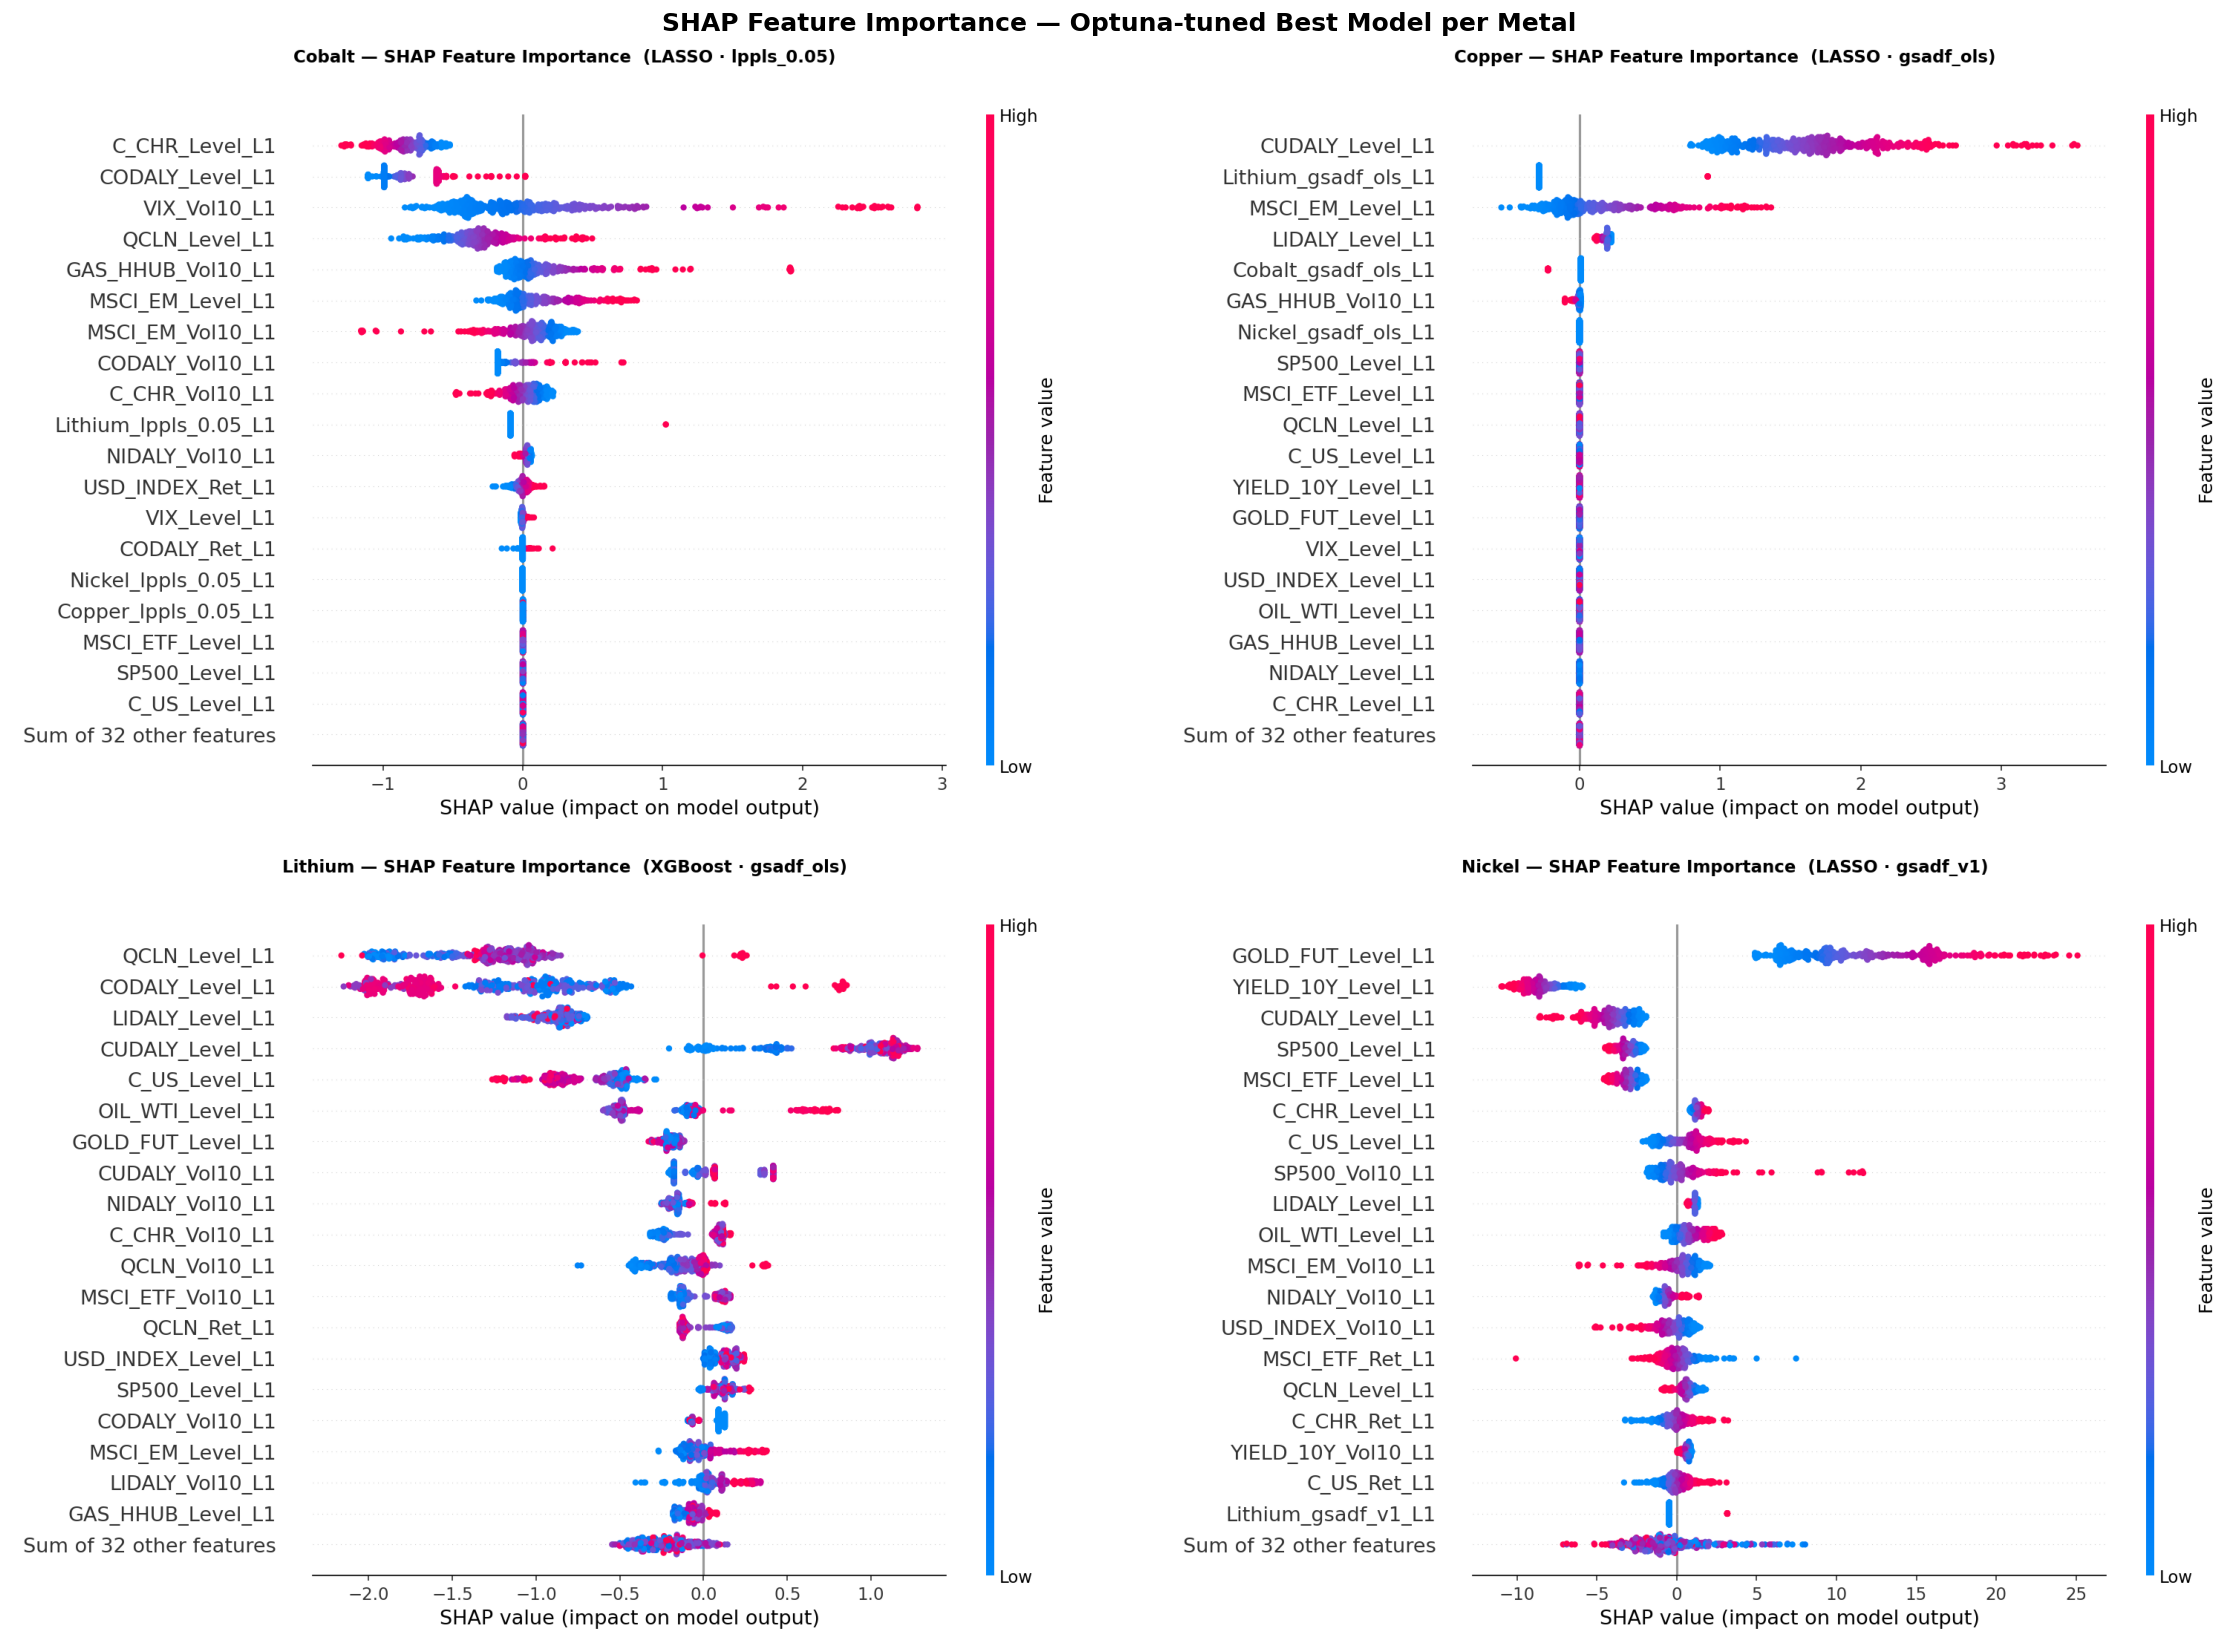

In [7]:
import os
from PIL import Image as PILImage

# ── Optuna improvement table ───────────────────────────────────────────────
opt_path = '../outputs/optuna_results.csv'
if os.path.exists(opt_path):
    df_opt = pd.read_csv(opt_path)
    print('Optuna Fine-tuning — AUC improvement over default hyperparameters:\n')
    print(f'{"Metal":>8s}  {"Variant":>14s}  {"Model":>10s}  '
          f'{"AUC_base":>8s}  {"AUC_tuned":>9s}  {"Δ":>6s}')
    print('-' * 65)
    for _, r in df_opt.iterrows():
        star = ' ★' if r.Delta_AUC > 0.01 else ''
        print(f'{r.Metal:>8s}  {r.Variant:>14s}  {r.Model:>10s}  '
              f'{r.AUC_base:>8.3f}  {r.AUC_tuned:>9.3f}  {r.Delta_AUC:>+6.3f}{star}')
    print('\n★ = meaningful improvement (Δ > 0.01)')
else:
    print('Run 02_model_training.ipynb first to generate optuna_results.csv')

# ── SHAP 2×2 overview ─────────────────────────────────────────────────────
shap_paths = {m: f'../outputs/shap_{m.lower()}.png'
              for m in ['Cobalt', 'Copper', 'Lithium', 'Nickel']}

if all(os.path.exists(p) for p in shap_paths.values()):
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    for ax, (metal, path) in zip(axes.flat, shap_paths.items()):
        img = PILImage.open(path)
        ax.imshow(np.array(img))
        ax.axis('off')
    plt.suptitle('SHAP Feature Importance — Optuna-tuned Best Model per Metal',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../outputs/03_shap_overview.png', dpi=120,
                bbox_inches='tight', facecolor='white')
    plt.show()
else:
    print('Run 02_model_training.ipynb first to generate SHAP plots.')


## 5. Visual: Price Charts with Best-Detected Bubbles

For each metal, show the price chart with the **best label variant** shaded.

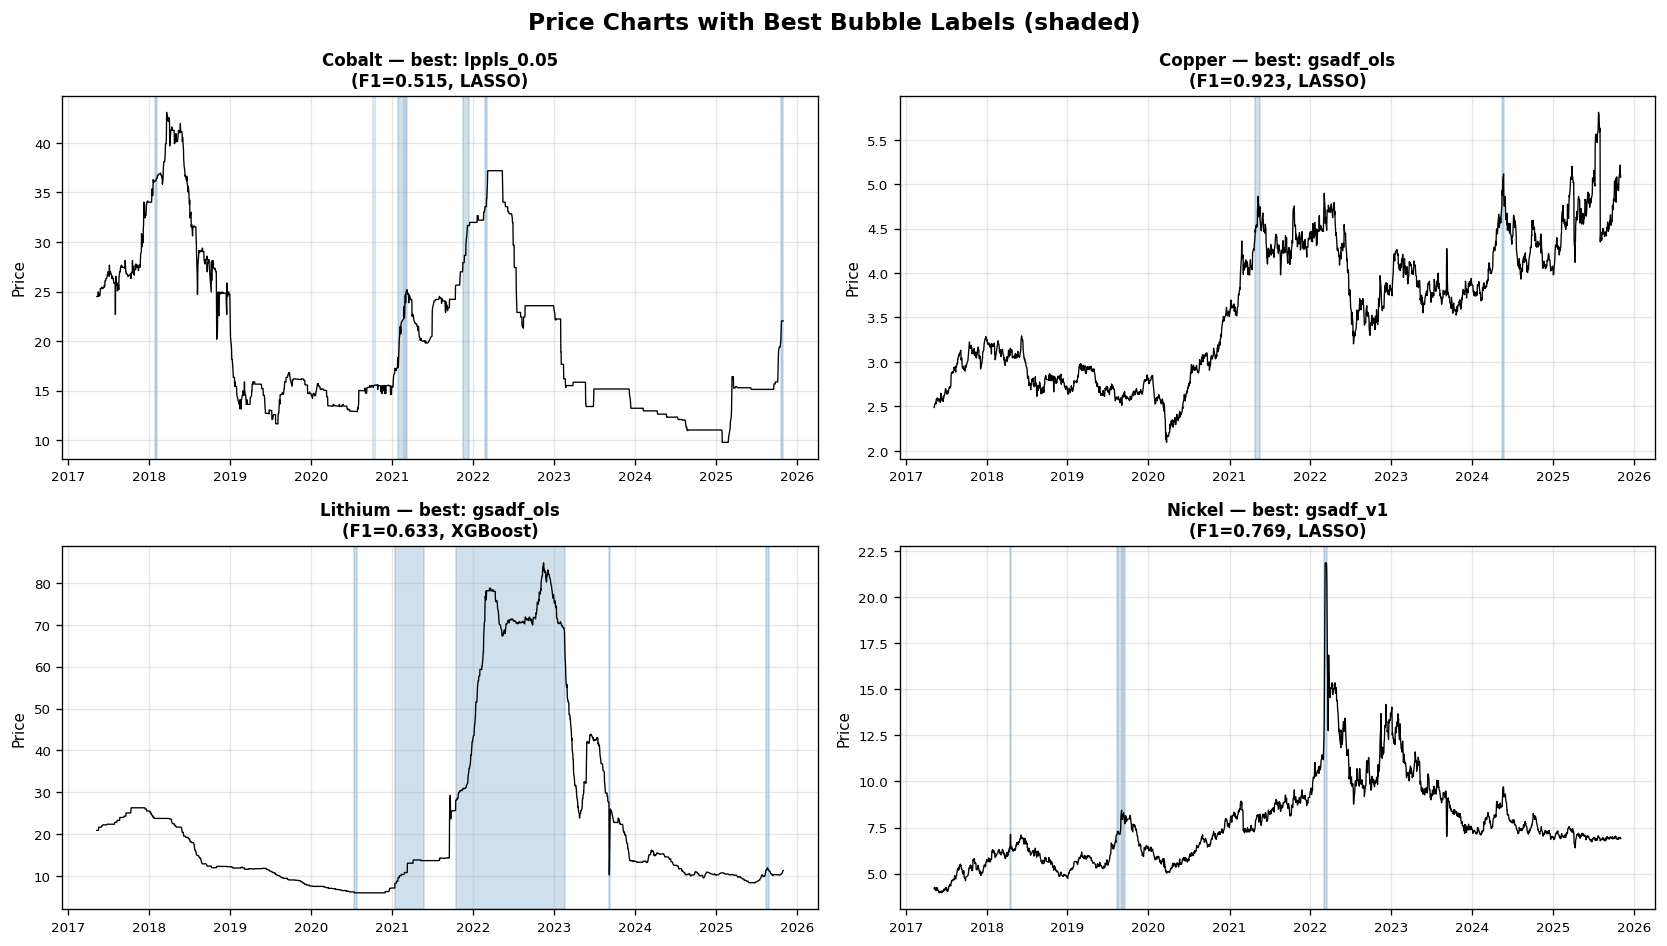

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for idx, (metal, col) in enumerate(METALS.items()):
    ax = axes.flat[idx]
    dates = df_labels['Date']
    ax.plot(dates, df_labels[col], color='black', lw=0.8, label='Price')

    # Best variant for this metal (by best F1)
    row    = pivot_best_f1.loc[metal]
    winner = row.idxmax()
    label_col = f'{metal}_{winner}'

    if label_col in df_labels.columns:
        arr  = df_labels[label_col].values
        in_b = False
        for i in range(len(arr)):
            if arr[i] == 1 and not in_b:
                s = dates.iloc[i]; in_b = True
            elif (arr[i] == 0 or i == len(arr) - 1) and in_b:
                ax.axvspan(s, dates.iloc[i], color='steelblue', alpha=0.25)
                in_b = False

    r = overall_best[overall_best.Metal == metal].iloc[0]
    ax.set_title(f'{metal} — best: {winner}\n(F1={r.F1:.3f}, {r.Model})',
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('Price', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Price Charts with Best Bubble Labels (shaded)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/03_best_bubbles.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


## 6. Key Findings

### GSADF vs LPPLS — Which Is Better?

**It depends on the metal:**

In [9]:
# ── GSADF vs LPPLS — fair comparison using MEAN F1 across all models ──────
# Group variants by detection method
GSADF_V = [v for v in VARIANTS if v.startswith('gsadf')]
LPPLS_V = [v for v in VARIANTS if v.startswith('lppls')]

print('GSADF vs Best LPPLS Variant per Metal  (mean F1 across all 5 models)')
print('Using mean-across-models removes the confound where a lucky model pairing')
print('makes one detection method look artificially better than another.\n')
print(f'{"Metal":>8s}  {"Method":>6s}  {"Best Variant":>22s}  '
      f'{"Mean F1":>7s}  {"Ceiling F1":>10s}  {"Best Model":>10s}  {"Winner":>8s}')
print('─' * 85)

for metal in METAL_ORDER:
    # Best GSADF variant by mean F1
    gsadf_means  = pivot_mean_f1.loc[metal, GSADF_V]
    best_gsadf_v = gsadf_means.idxmax()
    mean_gsadf   = gsadf_means.max()
    ceil_gsadf   = pivot_best_f1.loc[metal, best_gsadf_v]
    mod_gsadf    = pivot_best_model.loc[metal, best_gsadf_v]

    # Best LPPLS variant by mean F1
    lppls_means  = pivot_mean_f1.loc[metal, LPPLS_V]
    best_lppls_v = lppls_means.idxmax()
    mean_lppls   = lppls_means.max()
    ceil_lppls   = pivot_best_f1.loc[metal, best_lppls_v]
    mod_lppls    = pivot_best_model.loc[metal, best_lppls_v]

    winner = 'GSADF' if mean_gsadf >= mean_lppls else 'LPPLS'

    print(f'{metal:>8s}  {"GSADF":>6s}  {best_gsadf_v:>22s}  '
          f'{mean_gsadf:>7.3f}  {ceil_gsadf:>10.3f}  {str(mod_gsadf):>10s}')
    print(f'{"":>8s}  {"LPPLS":>6s}  {best_lppls_v:>22s}  '
          f'{mean_lppls:>7.3f}  {ceil_lppls:>10.3f}  {str(mod_lppls):>10s}  ← {winner}')
    print()


GSADF vs Best LPPLS Variant per Metal  (mean F1 across all 5 models)
Using mean-across-models removes the confound where a lucky model pairing
makes one detection method look artificially better than another.

   Metal  Method            Best Variant  Mean F1  Ceiling F1  Best Model    Winner
─────────────────────────────────────────────────────────────────────────────────────
  Cobalt   GSADF               gsadf_ols    0.325       0.366       LASSO
           LPPLS              lppls_0.10    0.293       0.415       LASSO  ← GSADF

  Copper   GSADF               gsadf_ols    0.689       0.923       LASSO
           LPPLS              lppls_0.10    0.273       0.325    CatBoost  ← GSADF

 Lithium   GSADF               gsadf_ols    0.564       0.633     XGBoost
           LPPLS       lppls_0.01_period    0.300       0.397     XGBoost  ← GSADF

  Nickel   GSADF                gsadf_v1    0.336       0.769       LASSO
           LPPLS       lppls_0.01_period    0.354       0.361       LASS

## 7. Conclusions

In [10]:
print('╔' + '═'*78 + '╗')
print('║' + ' CONCLUSIONS '.center(78) + '║')
print('╚' + '═'*78 + '╝')

GSADF_V = [v for v in VARIANTS if v.startswith('gsadf')]
LPPLS_V = [v for v in VARIANTS if v.startswith('lppls')]

# ── Experiment A summary ───────────────────────────────────────────────────
print('\n── EXPERIMENT A: Detection Method Quality (mean F1 across all models) ──\n')
for metal in METAL_ORDER:
    g_mean  = pivot_mean_f1.loc[metal, GSADF_V].max()
    g_best  = pivot_mean_f1.loc[metal, GSADF_V].idxmax()
    lp_mean = pivot_mean_f1.loc[metal, LPPLS_V].max()
    lp_best = pivot_mean_f1.loc[metal, LPPLS_V].idxmax()
    winner  = 'GSADF' if g_mean >= lp_mean else 'LPPLS'
    print(f'  {metal:8s}: GSADF best ({g_best}) mean={g_mean:.3f}  vs  '
          f'LPPLS best ({lp_best}) mean={lp_mean:.3f}  → {winner} wins')

print('''
  Insight: GSADF tends to produce more coherent, longer episodes that give models
  more training signal per bubble event. LPPLS (especially period variants) can
  outperform where bubbles are shorter and more frequent (Cobalt-style dynamics).
''')

# ── Experiment B summary ───────────────────────────────────────────────────
print('── EXPERIMENT B: Model Performance ──\n')
print('  Best model per variant (averaged across metals):')
for v in VARIANTS:
    if v in pivot_mv.columns:
        col = pivot_mv[v]
        best_m = col.idxmax()
        print(f'    {v:>24s}: {best_m:10s}  (mean F1={col.max():.3f})')

print('\n  Best model per metal (averaged across variants):')
for metal in METAL_ORDER:
    if metal in pivot_mm.columns:
        col    = pivot_mm[metal]
        best_m = col.idxmax()
        print(f'    {metal:>8s}: {best_m:10s}  (mean F1={col.max():.3f})')

print('''
  Insight: LASSO is competitive overall, especially on GSADF labels and for
  metals with clear mega-bubble periods. Tree models (LightGBM, XGBoost, CatBoost)
  excel where the bubble signal is subtle or nonlinear. Optuna tuning tends to
  help tree models more than LASSO.
''')

# ── Experiment C summary ───────────────────────────────────────────────────
print('── EXPERIMENT C: Optimal (Method + Model) per Metal ──\n')
print(f'  {"Metal":>8s}  {"Detection Method":>22s}  {"Model":>10s}  '
      f'{"F1":>5s}  {"AUC":>5s}  {"Episodes":>8s}  [Method]')
print('  ' + '─' * 70)
for _, r in overall_best.iterrows():
    method = 'GSADF' if r.Variant.startswith('gsadf') else 'LPPLS'
    print(f'  {r.Metal:>8s}  {r.Variant:>22s}  {r.Model:>10s}  '
          f'{r.F1:>5.3f}  {r.AUC:>5.3f}  {r.EpDet:>8s}  [{method}]')


╔══════════════════════════════════════════════════════════════════════════════╗
║                                 CONCLUSIONS                                  ║
╚══════════════════════════════════════════════════════════════════════════════╝

── EXPERIMENT A: Detection Method Quality (mean F1 across all models) ──

  Cobalt  : GSADF best (gsadf_ols) mean=0.325  vs  LPPLS best (lppls_0.10) mean=0.293  → GSADF wins
  Copper  : GSADF best (gsadf_ols) mean=0.689  vs  LPPLS best (lppls_0.10) mean=0.273  → GSADF wins
  Lithium : GSADF best (gsadf_ols) mean=0.564  vs  LPPLS best (lppls_0.01_period) mean=0.300  → GSADF wins
  Nickel  : GSADF best (gsadf_v1) mean=0.336  vs  LPPLS best (lppls_0.01_period) mean=0.354  → LPPLS wins

  Insight: GSADF tends to produce more coherent, longer episodes that give models
  more training signal per bubble event. LPPLS (especially period variants) can
  outperform where bubbles are shorter and more frequent (Cobalt-style dynamics).

── EXPERIMENT B: Model 